In [3]:
import pandas as pd
import numpy as np
df=pd.DataFrame( {
    "Employee_ID": [
        101, 102, 103, 104, 105, 106, 107, 108,
        109, 110, 111, 112, 113, 114, 115, 103
    ],

    "Department": [
        "IT", "HR", "Sales", "IT", "Finance", "Sales",
        "HR", "IT", "Finance", "Sales", "IT", "HR",
        "Finance", "Sales", "IT", "Sales"
    ],

    "Age": [
        24, 29, 31, 28, 35, 40, 27, 30,
        38, 45, np.nan, 32, 41, 36, 29, 31
    ],

    "Experience": [
        1, 4, 6, 3, 9, 14, 2, 5,
        12, 18, 2, 7, 15, 10, 4, 6
    ],

    "Salary": [
        30000, 42000, 50000, 45000, np.nan, 72000,
        38000, 52000, 68000, 90000, 34000, 48000,
        78000, 60000, 150000, 50000
    ],

    "Performance_Score": [
        6.5, 7.2, 8.1, 7.8, 8.5, 9.0, 6.9, 8.0,
        8.7, 9.2, 7.0, 7.5, 8.9, np.nan, 7.7, 8.1
    ],

    "Projects_Completed": [
        2, 3, 5, 4, 6, 8, 2, 5,
        7, 10, 3, 4, 9, 6, 5, 5
    ],

    "Training_Hours": [
        20, 15, 10, 25, 8, 5, 18, 12,
        6, 4, 22, 14, 7, 9, 16, 10
    ],

    "Job_Satisfaction": [
        7, 6, 8, 8, 7, 9, 6, 8,
        7, 9, 7, 6, 8, 8, 7, 8
    ]
})

In [4]:
df

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
0,101,IT,24.0,1,30000.0,6.5,2,20,7
1,102,HR,29.0,4,42000.0,7.2,3,15,6
2,103,Sales,31.0,6,50000.0,8.1,5,10,8
3,104,IT,28.0,3,45000.0,7.8,4,25,8
4,105,Finance,35.0,9,NaN,8.5,6,8,7
5,106,Sales,40.0,14,72000.0,9.0,8,5,9
6,107,HR,27.0,2,38000.0,6.9,2,18,6
7,108,IT,30.0,5,52000.0,8.0,5,12,8
8,109,Finance,38.0,12,68000.0,8.7,7,6,7
9,110,Sales,45.0,18,90000.0,9.2,10,4,9


In [5]:
df.shape

(16, 9)

In [6]:
df.isnull().sum()

Employee_ID           0
Department            0
Age                   1
Experience            0
Salary                1
Performance_Score     1
Projects_Completed    0
Training_Hours        0
Job_Satisfaction      0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         16 non-null     int64  
 1   Department          16 non-null     str    
 2   Age                 15 non-null     float64
 3   Experience          16 non-null     int64  
 4   Salary              15 non-null     float64
 5   Performance_Score   15 non-null     float64
 6   Projects_Completed  16 non-null     int64  
 7   Training_Hours      16 non-null     int64  
 8   Job_Satisfaction    16 non-null     int64  
dtypes: float64(3), int64(5), str(1)
memory usage: 1.3 KB


In [9]:
num_df=df.select_dtypes(include='number')

In [10]:
corr_mat=num_df.corr()

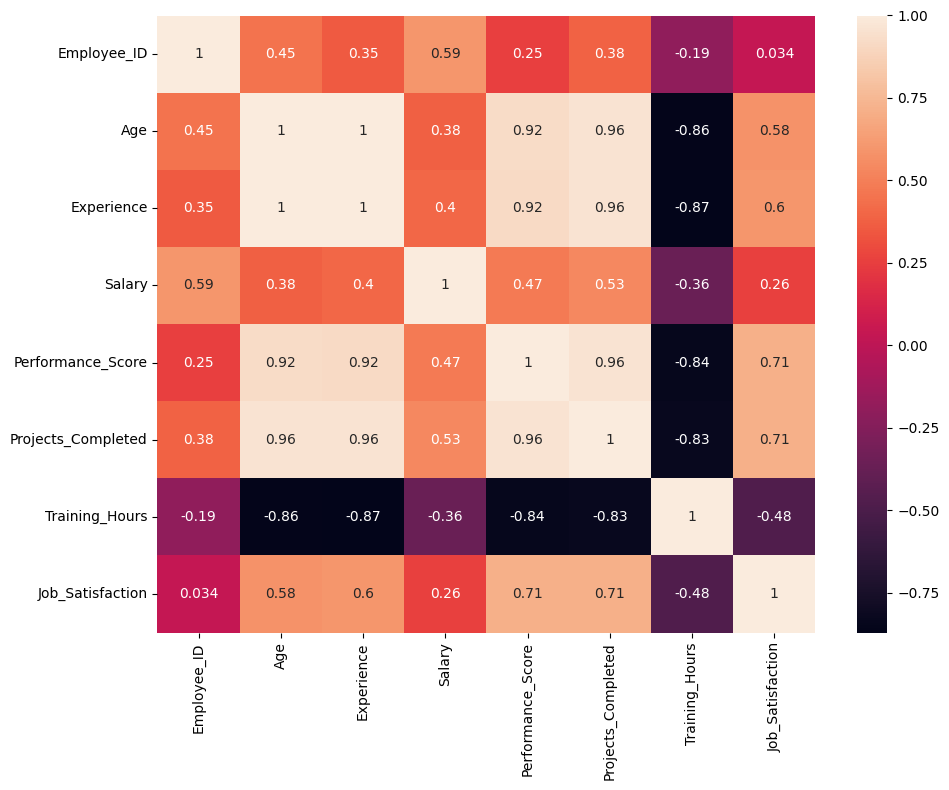

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_mat,annot=True)
plt.tight_layout()
plt.show()

In [18]:
new_df=df[df.duplicated()]

In [19]:
new_df

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
15,103,Sales,31.0,6,50000.0,8.1,5,10,8


In [ ]:
df=df.drop()

TypeError: DataFrame.dropna() takes 1 positional argument but 2 were given

In [21]:
df.head()

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
0,101,IT,24.0,1,30000.0,6.5,2,20,7
1,102,HR,29.0,4,42000.0,7.2,3,15,6
2,103,Sales,31.0,6,50000.0,8.1,5,10,8
3,104,IT,28.0,3,45000.0,7.8,4,25,8
4,105,Finance,35.0,9,NaN,8.5,6,8,7


In [22]:
Q1=num_df.quantile(0.25)
Q3=num_df.quantile(0.75)

IQR=Q3-Q1


In [24]:
Lower_Limit=Q1-1.5*IQR
Upper_Limit=Q3+1.5*IQR

In [31]:
Outliers=df[(num_df<Lower_Limit)|(num_df>Upper_Limit)]
Outliers.sum()

Employee_ID                0.0
Department                    
Age                        0.0
Experience                 0.0
Salary                150000.0
Performance_Score          0.0
Projects_Completed         0.0
Training_Hours             0.0
Job_Satisfaction           0.0
dtype: object

In [30]:
df[(Outliers).any(axis=1)]

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
14,115,IT,29.0,4,150000.0,7.7,5,16,7


In [32]:
df_capping=num_df.copy()

In [38]:
df_capping

,Employee_ID,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
0,101,24.0,1,30000.0,6.5,2,20,7
1,102,29.0,4,42000.0,7.2,3,15,6
2,103,31.0,6,50000.0,8.1,5,10,8
3,104,28.0,3,45000.0,7.8,4,25,8
4,105,35.0,9,NaN,8.5,6,8,7
5,106,40.0,14,72000.0,9.0,8,5,9
6,107,27.0,2,38000.0,6.9,2,18,6
7,108,30.0,5,52000.0,8.0,5,12,8
8,109,38.0,12,68000.0,8.7,7,6,7
9,110,45.0,18,90000.0,9.2,10,4,9


In [40]:
df.head()

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
0,101,IT,24.0,1,30000.0,6.5,2,20,7
1,102,HR,29.0,4,42000.0,7.2,3,15,6
2,103,Sales,31.0,6,50000.0,8.1,5,10,8
3,104,IT,28.0,3,45000.0,7.8,4,25,8
4,105,Finance,35.0,9,NaN,8.5,6,8,7


In [45]:
exp=df.groupby('Employee_ID')['Experience'].sum()
exp

Employee_ID
101     1
102     4
103    12
104     3
105     9
106    14
107     2
108     5
109    12
110    18
111     2
112     7
113    15
114    10
115     4
Name: Experience, dtype: int64

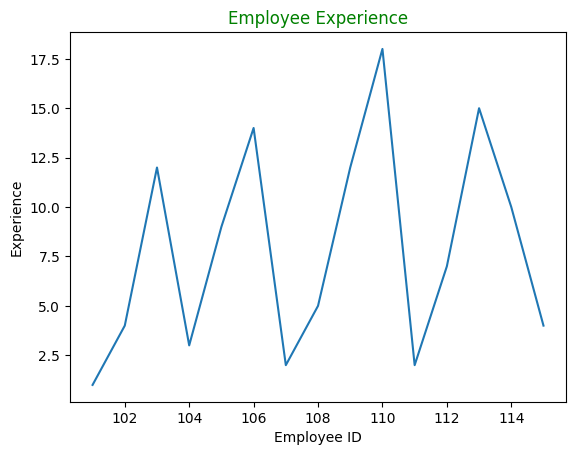

In [48]:
import matplotlib.pyplot as plt
plt.title("Employee Experience",color='Green')
plt.xlabel("Employee ID")
plt.ylabel("Experience")
plt.plot(exp.index,exp)
plt.show()

In [49]:
df.head()

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
0,101,IT,24.0,1,30000.0,6.5,2,20,7
1,102,HR,29.0,4,42000.0,7.2,3,15,6
2,103,Sales,31.0,6,50000.0,8.1,5,10,8
3,104,IT,28.0,3,45000.0,7.8,4,25,8
4,105,Finance,35.0,9,NaN,8.5,6,8,7


In [52]:
res=df.groupby('Department')['Performance_Score'].sum()
res

Department
Finance    26.1
HR         21.6
IT         37.0
Sales      34.4
Name: Performance_Score, dtype: float64

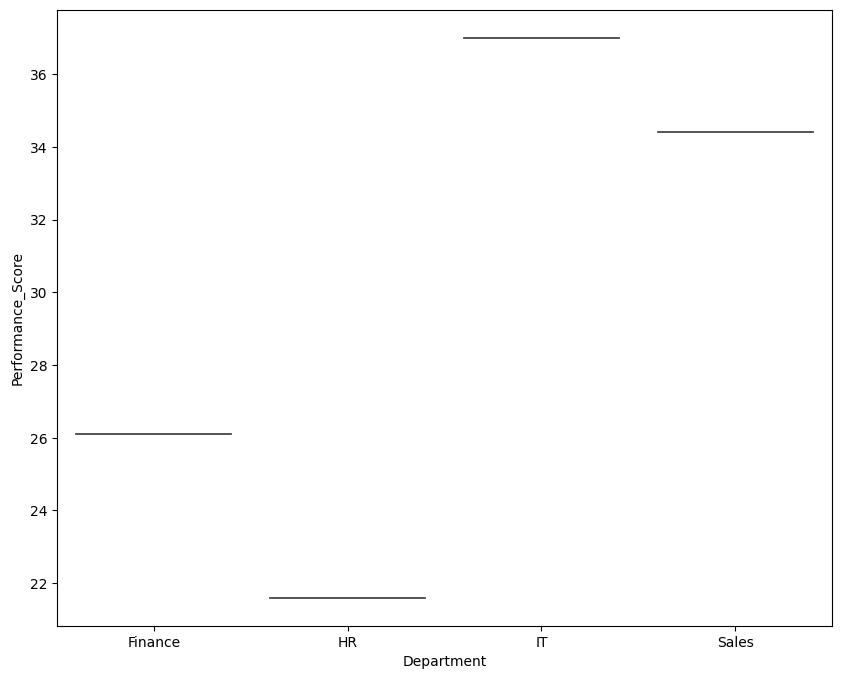

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.violinplot(x=res.index,y=res)
plt.show()

In [54]:
df.head()

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction
0,101,IT,24.0,1,30000.0,6.5,2,20,7
1,102,HR,29.0,4,42000.0,7.2,3,15,6
2,103,Sales,31.0,6,50000.0,8.1,5,10,8
3,104,IT,28.0,3,45000.0,7.8,4,25,8
4,105,Finance,35.0,9,NaN,8.5,6,8,7


In [59]:
res=df.groupby('Department')['Employee_ID'].agg('count')
res

Department
Finance    3
HR         3
IT         5
Sales      5
Name: Employee_ID, dtype: int64

In [60]:
df['Yearly salary']=df['Salary']*12

In [61]:
df.head()

,Employee_ID,Department,Age,Experience,Salary,Performance_Score,Projects_Completed,Training_Hours,Job_Satisfaction,Yearly salary
0,101,IT,24.0,1,30000.0,6.5,2,20,7,360000.0
1,102,HR,29.0,4,42000.0,7.2,3,15,6,504000.0
2,103,Sales,31.0,6,50000.0,8.1,5,10,8,600000.0
3,104,IT,28.0,3,45000.0,7.8,4,25,8,540000.0
4,105,Finance,35.0,9,NaN,8.5,6,8,7,NaN
